In [8]:
# 1) Imports
import os
from src.visualization import Visualizer
import pandas as pd
import numpy as np
from utils import setrootdir
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns

import networkx as nx
from src.community_detection import (
    detect_communities,
    communities_dataframe,
    community_report,
    compare_community_algorithms,
    partition_to_mapping
)

setrootdir("ppgcc-coautorias")


'Directory ppgcc-coautorias successfully loaded as current working directory.'

In [9]:
load_dotenv()

DATASET_DIRECTORY = os.getenv("DATASET_DIRECTORY")
METADATA_FILE = os.getenv("METADATA_FILE")

In [10]:
visualizer = Visualizer(
    data_dir=DATASET_DIRECTORY,
    metadata_file=METADATA_FILE,
    step_directory="04-visualization"
)

In [11]:
df_productions = visualizer.read_parquet(step="03-transformation", name="productions")
df_productions.head()

,production_id,name,citation,nid,lattes_id,institution,production,aid,authors,type,year,issn
0,0,Vitor Valério de Souza Campos,"[Vitor Valério de Souza Campos, CAMPOS, VITOR ...",1714,2809980784526040,UEL,Review and comparison of works on heterogeneou...,1714,Vitor Valério de Souza Campos,PERIODICO,2021,16790375
1,0,Vitor Valério de Souza Campos,"[Vitor Valério de Souza Campos, CAMPOS, VITOR ...",1714,2809980784526040,UEL,Review and comparison of works on heterogeneou...,778,Jacques Duílio Brancher,PERIODICO,2021,16790375
2,0,Vitor Valério de Souza Campos,"[Vitor Valério de Souza Campos, CAMPOS, VITOR ...",1714,2809980784526040,UEL,Review and comparison of works on heterogeneou...,39238,"FARIAS, FRANCYELCYO PUSSI",PERIODICO,2021,16790375
3,0,Vitor Valério de Souza Campos,"[Vitor Valério de Souza Campos, CAMPOS, VITOR ...",1714,2809980784526040,UEL,Review and comparison of works on heterogeneou...,75104,"MIONI, JOSÉ LUIZ VILLELA MARCONDES",PERIODICO,2021,16790375
4,0,Vitor Valério de Souza Campos,"[Vitor Valério de Souza Campos, CAMPOS, VITOR ...",1714,2809980784526040,UEL,Review and comparison of works on heterogeneou...,14939,"BRAHIM, PEDRO LUIZ GARBIM",PERIODICO,2021,16790375


In [12]:
def check_sarmento_natividade(citation):
    check_sarmento = False
    check_natividade = False

    for author in citation:
        if "SARMENTO" in author.upper():
            check_sarmento = True
        if "BARROS" in author.upper():
            check_natividade = True
    
    return check_sarmento and check_natividade

df_productions[df_productions["citation"].map(lambda x: check_sarmento_natividade(x))]

,production_id,name,citation,nid,lattes_id,institution,production,aid,authors,type,year,issn


In [13]:
df_adjacency = visualizer.frame_coauthorship_adjacency_matrix(
    df_productions,
    remove_isolated=True
)

df_adjacency

,0,1,2,3,4,5,6,7,8,9,...,1746,1747,1748,1749,1750,1751,1752,1753,1754,1755
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1751,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1752,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,0
1753,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1754,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0


In [14]:
# Configuração da detecção de comunidades
METHOD = "louvain"
RESOLUTION = 1.0
SEED = 42
MIN_TOTAL_W = 10  # Filtro mínimo para rankings de autores

# Construir grafo de coautoria
G = nx.from_pandas_adjacency(df_adjacency)

In [15]:
# (OPCIONAL) Análise de sensibilidade: testar diferentes resolutions
# Descomente se quiser explorar o impacto do parâmetro resolution

resolutions = [1.0, 0.8, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]
rows = []
for r in resolutions:
    part = detect_communities(G, method="louvain", weight="weight", resolution=r, seed=42)
    rows.append({"resolution": r, **community_report(G, part, weight="weight")})
pd.DataFrame(rows)[["resolution", "num_communities", "largest_community", "mean_community_size", "modularity"]]

,resolution,num_communities,largest_community,mean_community_size,modularity
0,1.0,36.0,146.0,47.916667,0.781088
1,0.8,28.0,218.0,61.607143,0.778714
2,0.6,25.0,239.0,69.000000,0.772568
3,0.5,20.0,261.0,86.250000,0.766256
4,0.4,17.0,280.0,101.470588,0.758625
5,0.3,13.0,322.0,132.692308,0.743179
6,0.2,8.0,663.0,215.625000,0.650452
7,0.1,4.0,1541.0,431.250000,0.235050


In [16]:
# Detectar comunidades
partition = detect_communities(
    G,
    method=METHOD,
    weight="weight",
    resolution=RESOLUTION,
    seed=SEED,
)

df_comm = communities_dataframe(partition)
global_metrics = community_report(G, partition, weight="weight")

print(f"Comunidades detectadas: {global_metrics['num_communities']}")
print(f"Modularidade: {global_metrics['modularity']:.3f}")
df_comm.head()

Comunidades detectadas: 36.0
Modularidade: 0.781


,node,community
0,1,0
1,101,0
2,1013,0
3,1017,0
4,1019,0


In [17]:
# (OPCIONAL) Comparar algoritmos de detecção de comunidades
# Descomente se quiser explorar diferentes métodos

# df_compare = compare_community_algorithms(
#     G,
#     methods=["greedy_modularity", "louvain", "leiden"],
#     default_weight="weight",
#     method_params={
#         "greedy_modularity": {"resolution": 0.6},
#         "louvain": {"resolution": 0.6, "seed": 42},
#         "leiden": {"resolution": 0.6, "seed": 42},
#     },
# )
# df_compare

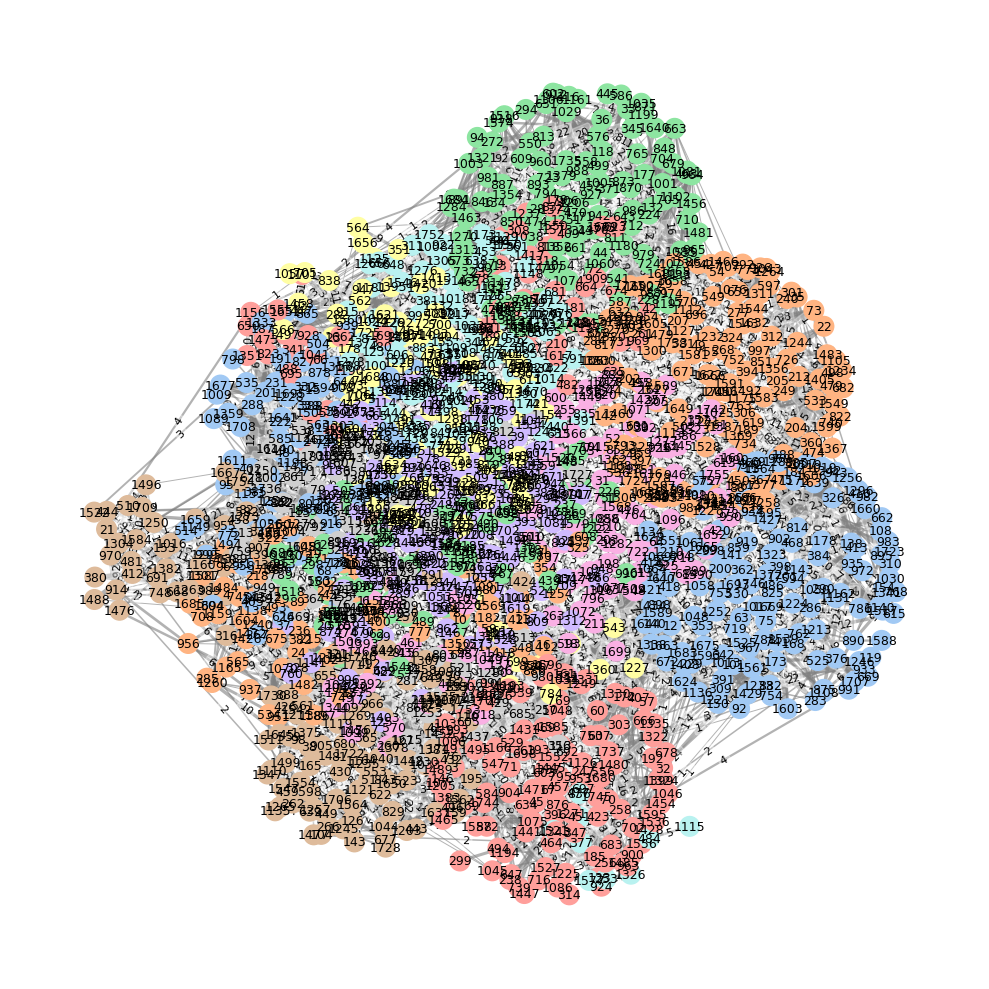

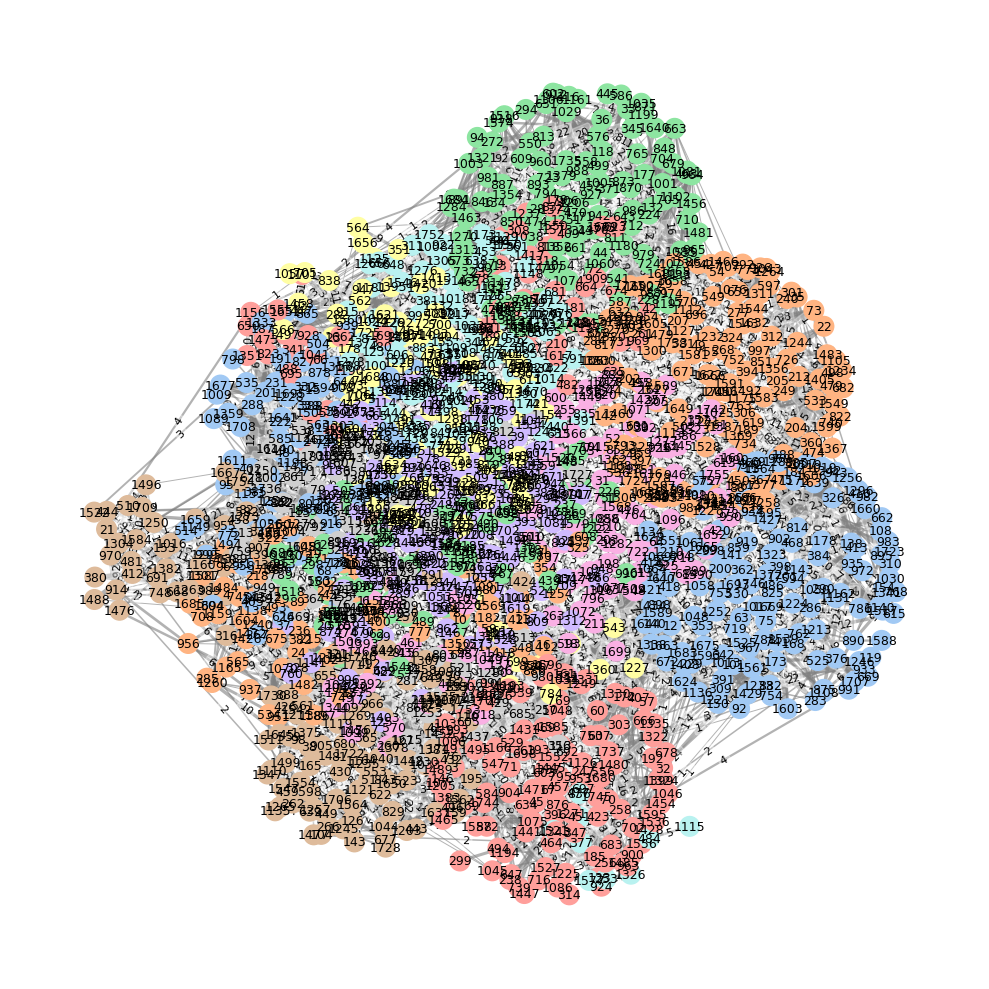

In [18]:
# Visualizar rede com comunidades
df_edges = nx.to_pandas_edgelist(G).rename(columns={"weight": "n_coauthorships"})
fig = visualizer.plot_coauthorship_network(
    df_edges,
    community_method=METHOD,
    community_kwargs={"resolution": RESOLUTION, "seed": SEED},
    filename=f"coauthorship_network_{METHOD}"
)
fig

In [19]:
# Preparar edgelist com comunidades
m = partition_to_mapping(partition) # cria um dicionário do tipo autor -> comunidade.
df_e = nx.to_pandas_edgelist(G) #  transforma o grafo em uma tabela de arestas, onde cada linha é uma ligação entre dois autores.
df_e["c_source"] = df_e["source"].map(m)
df_e["c_target"] = df_e["target"].map(m)
# adicionam, para cada ponta da aresta, a comunidade do autor de origem e do autor de destino.
df_e["edge_type"] = np.where(
    df_e["c_source"] == df_e["c_target"], 
    "intra", 
    "inter"
) # classifica a aresta como "intra" se os autores de origem e destino pertencem à mesma comunidade, ou "inter" caso contrário.

# Resumo de arestas por tipo
edge_strength = df_e.groupby("edge_type")["weight"].sum()
print(f"Peso intra-comunidade: {int(edge_strength.get('intra', 0))}")
print(f"Peso inter-comunidade: {int(edge_strength.get('inter', 0))}")

df_e.head()

Peso intra-comunidade: 62419
Peso inter-comunidade: 12673


,source,target,weight,c_source,c_target,edge_type
0,0,235,1,8,8,intra
1,0,364,7,8,8,intra
2,0,428,2,8,11,inter
3,0,592,13,8,8,intra
4,0,654,1,8,8,intra


#### Arestas Intra e Inter-Comunidades

##### Classificação das Arestas

As arestas da rede de coautoria podem ser classificadas em dois tipos:

- **Intra**: conecta dois autores **da mesma comunidade**.
- **Inter**: conecta autores **de comunidades diferentes**.

##### Exemplo

- Se **A** e **B** pertencem à comunidade **3**, a aresta **A–B** é **intra**.  
- Se **A** pertence à comunidade **3** e **C** à comunidade **7**, a aresta **A–C** é **inter**.

##### Significado do *Weight*

O **weight** (peso) da aresta representa a **intensidade da colaboração** entre dois autores, normalmente definida como o **número de artigos escritos em coautoria**.

Assim:

- **Peso intra-comunidade**: soma dos pesos das arestas entre autores da mesma comunidade.
- **Peso inter-comunidade**: soma dos pesos das arestas entre autores de comunidades diferentes.

##### Interpretação

- **Peso intra alto** → colaboração concentrada **dentro das comunidades**.  
- **Peso inter alto** → colaboração **entre diferentes comunidades**.

In [20]:
def calculate_entropy(group_series, weight_col='weight'):
    """Calcula entropia de Shannon para distribuição de pesos."""
    w = group_series[weight_col].to_numpy()
    s = w.sum()
    if s <= 0:
        return 0.0
    p = w / s
    return float(-(p * np.log(p + 1e-12)).sum())


def mode_value(series):
    """Retorna o valor mais frequente de uma série."""
    s = series.dropna()
    if s.empty:
        return None
    return s.value_counts().index[0]


def zscore_by_group(series):
    """Calcula z-score dentro de grupos (usado com transform)."""
    mu = series.mean()
    sd = series.std(ddof=0)
    if sd == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - mu) / sd


def classify_role(row, z_hub=2.5, p_connector=0.62):
    """Classifica papel do nó baseado em z-score e participation coefficient."""
    z = row["z_intra"]
    p = row["participation_P"]
    if z >= z_hub and p >= p_connector:
        return "connector_hub"
    if z >= z_hub and p < p_connector:
        return "provincial_hub"
    if z < z_hub and p >= p_connector:
        return "connector"
    return "peripheral"

print("✅ Funções utilitárias carregadas")

✅ Funções utilitárias carregadas


In [21]:
# Calcular métricas por comunidade
df_intra = df_e[df_e["edge_type"] == "intra"]
df_inter = df_e[df_e["edge_type"] == "inter"]

# Pesos intra e inter
intra_w = df_intra.groupby("c_source")["weight"].sum()
ext_w = (
    df_inter.groupby("c_source")["weight"].sum()
    .add(df_inter.groupby("c_target")["weight"].sum(), fill_value=0)
)

# Comunidades parceiras
partners = pd.concat([
    df_inter[["c_source", "c_target"]].rename(columns={"c_source": "c", "c_target": "p"}),
    df_inter[["c_target", "c_source"]].rename(columns={"c_target": "c", "c_source": "p"}),
], ignore_index=True)
n_partners = partners.groupby("c")["p"].nunique()

# Entropia de conexões externas
partners_w = pd.concat([
    df_inter[["c_source", "c_target", "weight"]].rename(columns={"c_source": "c", "c_target": "p"}),
    df_inter[["c_target", "c_source", "weight"]].rename(columns={"c_target": "c", "c_source": "p"}),
], ignore_index=True)
ext_entropy = partners_w.groupby("c").apply(calculate_entropy, include_groups=False)

# Consolidar perfil
summary = (
    df_comm.groupby("community").size()
    .rename("num_nodes")
    .to_frame()
    .assign(
        intra_weight=intra_w,
        external_strength_w=ext_w,
        n_partner_communities=n_partners,
        external_entropy=ext_entropy
    )
    .fillna(0)
)
summary["external_share"] = (
    summary["external_strength_w"] / 
    (summary["external_strength_w"] + summary["intra_weight"])
).fillna(0)

summary = summary.sort_values("num_nodes", ascending=False).reset_index()
summary.head(15)

,community,num_nodes,intra_weight,external_strength_w,n_partner_communities,external_entropy,external_share
0,0,146,4547,1449.0,32.0,5.937898,0.241661
1,1,139,5273,2722.0,30.0,6.478572,0.340463
2,2,111,2869,1181.0,32.0,5.666082,0.291605
3,3,109,3767,1243.0,27.0,5.804010,0.248104
4,4,105,3579,1777.0,32.0,6.024473,0.331777
5,5,96,4919,2441.0,31.0,6.080588,0.331658
6,6,94,3724,1690.0,29.0,5.943196,0.312154
7,7,93,3968,1903.0,30.0,5.823261,0.324136
8,8,89,2503,922.0,27.0,5.504424,0.269197
9,9,83,2463,1491.0,28.0,5.993564,0.377086


Essa tabela `summary` em 06-jc-community.ipynb resume cada comunidade da rede. Cada linha é uma comunidade. As colunas dizem tamanho, força interna, força externa e diversidade das conexões.

As colunas são estas:

- `community`
  É o identificador da comunidade.

- `num_nodes`
  Quantos autores existem naquela comunidade. É o tamanho da comunidade.

- `intra_weight`
  Soma dos pesos das colaborações entre autores da mesma comunidade. Mostra a força interna do grupo. Valor alto = a comunidade colabora muito dentro dela mesma.

- `external_strength_w`
  Soma dos pesos das colaborações da comunidade com outras comunidades. Mostra a força externa do grupo. Valor alto = a comunidade se conecta bastante com outros grupos.

- `n_partner_communities`
  Quantas comunidades diferentes ela alcança. Não mede intensidade, mede quantidade de parceiros.

- `external_entropy`
  Mede a diversidade dessas conexões externas. Valor baixo = a comunidade fala com poucas comunidades ou concentra quase tudo em uma só. Valor alto = a comunidade distribui suas conexões externas entre vários parceiros.

- `external_share`
  Mostra a proporção da força total que está voltada para fora. É calculada assim:

  $$
  external\_share =
  \frac{external\_strength\_w}
  {external\_strength\_w + intra\_weight}
  $$

  Interpretação:
  valor baixo = comunidade mais fechada
  valor alto = comunidade mais aberta para fora

Uma forma bem simples de entender:

- `num_nodes` = tamanho
- `intra_weight` = força dentro do grupo
- `external_strength_w` = força fora do grupo
- `n_partner_communities` = com quantos grupos ela se conecta
- `external_entropy` = quão espalhadas são essas conexões
- `external_share` = quanto da colaboração está voltada para fora

Exemplo de leitura de uma linha. Se uma comunidade tiver:

- `num_nodes = 40`
- `intra_weight = 100`
- `external_strength_w = 25`
- `n_partner_communities = 4`
- `external_entropy` alto
- `external_share = 0.20`

isso significa:
ela tem 40 autores, colabora muito mais internamente do que externamente, se conecta com 4 outras comunidades, distribui essas conexões de forma relativamente diversa, e 20% da força total dela está fora da própria comunidade.

In [22]:
# Calcular métricas de papéis dos autores (roles)
nodes_list = list(G.nodes())

# 1) Força total de cada nó
strength_total = dict(G.degree(weight="weight"))

# 2) Força intra-comunidade
df_intra_agg = (
    df_intra.groupby("c_source")["weight"]
    .sum()
    .to_dict()
)
strength_intra = {node: df_intra_agg.get(m.get(node, -1), 0) for node in nodes_list}

# 3) Força externa
strength_external = {node: strength_total.get(node, 0) - strength_intra.get(node, 0) for node in nodes_list}

# 4) Participation coefficient (P)
def calc_participation(node):
    node_comm = m.get(node)
    k_total = strength_total.get(node, 0)
    if k_total == 0:
        return 0.0
    
    # Somar pesos para cada comunidade vizinha
    comm_weights = {}
    for _, neighbor, data in G.edges(node, data=True):
        neigh_comm = m.get(neighbor)
        w = data.get("weight", 1)
        comm_weights[neigh_comm] = comm_weights.get(neigh_comm, 0) + w
    
    # P = 1 - sum((k_c / k)^2)
    p_sum = sum((w / k_total) ** 2 for w in comm_weights.values())
    return 1.0 - p_sum

participation = {node: calc_participation(node) for node in nodes_list}

# 5) Criar dataframe base
df_nodes_roles = pd.DataFrame({
    "node": nodes_list,
    "community": [m.get(node) for node in nodes_list],
    "strength_w": [strength_total.get(node, 0) for node in nodes_list],
    "strength_intra_w": [strength_intra.get(node, 0) for node in nodes_list],
    "strength_external_w": [strength_external.get(node, 0) for node in nodes_list],
    "participation_P": [participation.get(node, 0) for node in nodes_list]
})

# 6) Calcular z-score intra-comunidade por comunidade
df_nodes_roles["z_intra"] = (
    df_nodes_roles.groupby("community")["strength_intra_w"]
    .transform(zscore_by_group)
)

# 7) Classificar papéis
df_nodes_roles["role"] = df_nodes_roles.apply(classify_role, axis=1)

# Resumo de papéis
print("Distribuição de papéis:")
print(df_nodes_roles["role"].value_counts())
print(f"\nTotal de autores: {len(df_nodes_roles)}")

df_nodes_roles.head(10)

Distribuição de papéis:
role
peripheral    1540
connector      185
Name: count, dtype: int64

Total de autores: 1725


,node,community,strength_w,strength_intra_w,strength_external_w,participation_P,z_intra,role
0,0,8,108,2503,-2395,0.141289,0.0,peripheral
1,1,0,51,4547,-4496,0.075356,0.0,peripheral
2,2,14,54,2036,-1982,0.000000,0.0,peripheral
3,3,27,24,402,-378,0.538194,0.0,peripheral
4,4,15,520,2667,-2147,0.328499,0.0,peripheral
5,5,9,20,2463,-2443,0.610000,0.0,peripheral
6,6,8,90,2503,-2413,0.000000,0.0,peripheral
7,7,0,11,4547,-4536,0.396694,0.0,peripheral
8,8,9,2,2463,-2461,0.000000,0.0,peripheral
9,9,21,43,679,-636,0.571120,0.0,peripheral


Nessa célula, a tabela `df_nodes_roles` vira uma ficha de cada autor na rede. Cada linha é um autor. As colunas tentam mostrar em que comunidade ele está, o quanto ele colabora e qual papel ele exerce.

As colunas são estas:

- `node`
  É o identificador do autor.

- `community`
  É a comunidade à qual esse autor pertence.

- `strength_w`
  É a força total de colaboração do autor. Em termos simples: soma de todos os pesos das conexões dele. Se o autor publicou com muita gente, ou publicou muitas vezes com os mesmos coautores, esse valor cresce.

- `strength_intra_w`
  É a força de colaboração dentro da própria comunidade. A ideia é medir quanto o autor colabora com pessoas do mesmo grupo.

- `strength_external_w`
  É a força de colaboração fora da comunidade. Mostra quanto o autor colabora com pessoas de outros grupos.

- `participation_P`
  É o coeficiente de participação. Ele mede quão espalhadas estão as colaborações do autor entre diferentes comunidades.
  Interpretação:
  valor baixo = colabora mais concentrado no próprio grupo
  valor alto = colabora mais distribuído entre vários grupos

- `z_intra`
  É o z-score da força intra-comunidade. Ele compara o autor com os outros autores da mesma comunidade.
  Interpretação:
  valor alto = esse autor se destaca dentro do próprio grupo
  valor perto de 0 = ele está mais próximo da média do grupo
  valor baixo = ele é menos central dentro da comunidade

- `role`
  É a classificação final do autor. Ela usa `z_intra` e `participation_P` para dizer o papel dele na rede.

Os papéis são:

- `peripheral`
  Autor mais local, pouco destacado e pouco conectado para fora.

- `connector`
  Autor que faz pontes com outras comunidades.

- `provincial_hub`
  Autor muito forte dentro da própria comunidade, mas pouco voltado para fora.

- `connector_hub`
  Autor forte dentro da comunidade e também importante para ligar comunidades diferentes.

Uma leitura simples da tabela é:

- `strength_w` diz quanto o autor colabora no total
- `strength_intra_w` diz quanto ele colabora dentro do próprio grupo
- `strength_external_w` diz quanto ele colabora fora do grupo
- `participation_P` diz quão espalhadas são essas conexões
- `z_intra` diz o quanto ele é importante dentro do grupo
- `role` resume o papel dele

Um ponto importante sobre esta célula: a intenção de `strength_intra_w` é ser uma medida por autor, mas neste trecho ela está sendo construída a partir de um agregado por comunidade. Isso ajuda a explicar por que mais adiante você tem outra célula que recalcula `strength_intra_w` por nó antes de fazer o gráfico. Ou seja: conceitualmente a coluna significa “força interna do autor”, mas nesta célula ela funciona mais como uma aproximação.

In [23]:
# Criar mapeamentos nid → instituição e nid → nome
node_to_inst = (
    df_productions.groupby("nid")["institution"]
    .agg(mode_value)
    .to_dict()
)

node_to_name = (
    df_productions.groupby("nid")["name"]
    .agg(mode_value)
    .to_dict()
)

# Enriquecer df_nodes_roles
df_nodes_roles["institution"] = df_nodes_roles["node"].map(node_to_inst)
df_nodes_roles["name"] = df_nodes_roles["node"].map(node_to_name)

# Diagnóstico de cobertura
coverage_inst = df_nodes_roles["institution"].notna().mean()
coverage_name = df_nodes_roles["name"].notna().mean()

print(f"Cobertura instituição: {coverage_inst:.1%}")
print(f"Cobertura nome: {coverage_name:.1%}")

df_nodes_roles[["node", "name", "institution", "community", "role", "participation_P", "z_intra"]].head(10)

Cobertura instituição: 100.0%
Cobertura nome: 100.0%


,node,name,institution,community,role,participation_P,z_intra
0,0,Abel Guilhermino da Silva Filho,UFPE,8,peripheral,0.141289,0.0
1,1,Abilio Pereira de Lucena Filho,UFRJ-COMP,0,peripheral,0.075356,0.0
2,2,Adair Santa Catarina,UNIOESTE,14,peripheral,0.000000,0.0
3,3,Ademir Aparecido Constantino,UEM,27,peripheral,0.538194,0.0
4,4,Adenauer Correa Yamin,UFPEL,15,peripheral,0.328499,0.0
5,5,Adenilso da Silva Simão,USP-SC,9,peripheral,0.610000,0.0
6,6,Adenilton José da Silva,UFPE,8,peripheral,0.000000,0.0
7,7,Adiel Teixeira de Almeida Filho,UFPE,0,peripheral,0.396694,0.0
8,8,Adilson Luiz Bonifácio,UEL,9,peripheral,0.000000,0.0
9,9,Adler Diniz de Souza,UNIFEI,21,peripheral,0.571120,0.0


In [24]:
# Calcular métricas de colaboração inter-institucional por autor
df_author_inst_edges = df_e.copy()
df_author_inst_edges["inst_u"] = df_author_inst_edges["source"].map(node_to_inst)
df_author_inst_edges["inst_v"] = df_author_inst_edges["target"].map(node_to_inst)
df_author_inst_edges = df_author_inst_edges.dropna(subset=["inst_u", "inst_v"])
df_author_inst_edges["is_interinst"] = df_author_inst_edges["inst_u"] != df_author_inst_edges["inst_v"]

# Agregar por autor (source)
author_total_w = df_author_inst_edges.groupby("source")["weight"].sum().rename("total_w")
author_interinst_w = (
    df_author_inst_edges[df_author_inst_edges["is_interinst"]]
    .groupby("source")["weight"]
    .sum()
    .rename("interinst_w")
)

df_author_inst = pd.DataFrame({
    "node": author_total_w.index,
    "total_w": author_total_w.values,
    "interinst_w": author_interinst_w.reindex(author_total_w.index, fill_value=0).values
})

df_author_inst["interinst_share"] = (
    df_author_inst["interinst_w"] / df_author_inst["total_w"]
).fillna(0)

print(f"Autores com colaborações inter-institucionais: {(df_author_inst['interinst_w'] > 0).sum()}")
print(f"Média de participação inter-institucional: {df_author_inst['interinst_share'].mean():.1%}")

df_author_inst.head(10)

Autores com colaborações inter-institucionais: 1227
Média de participação inter-institucional: 46.5%


,node,total_w,interinst_w,interinst_share
0,0,108,96,0.888889
1,1,51,24,0.470588
2,2,54,0,0.000000
3,3,24,2,0.083333
4,4,520,167,0.321154
5,5,20,6,0.300000
6,6,90,44,0.488889
7,7,11,0,0.000000
8,9,43,7,0.162791
9,10,22,0,0.000000


In [25]:
# Agregar rede de autores para nível institucional
inst_df_e = df_e.copy()
inst_df_e["inst_u"] = inst_df_e["source"].map(node_to_inst)
inst_df_e["inst_v"] = inst_df_e["target"].map(node_to_inst)
inst_df_e = inst_df_e.dropna(subset=["inst_u", "inst_v"])

# Normalizar pares (não-direcionado)
a, b = inst_df_e["inst_u"].to_numpy(), inst_df_e["inst_v"].to_numpy()
inst_df_e["inst_min"] = np.where(a <= b, a, b)
inst_df_e["inst_max"] = np.where(a <= b, b, a)
inst_df_e["is_interinst"] = inst_df_e["inst_min"] != inst_df_e["inst_max"]

# Agregar pesos
inst_edges = (
    inst_df_e.groupby(["inst_min", "inst_max"])["weight"]
    .sum()
    .reset_index(name="collab_weight")
    .sort_values("collab_weight", ascending=False)
)

# Criar grafo institucional
G_inst = nx.from_pandas_edgelist(inst_edges, "inst_min", "inst_max", edge_attr="collab_weight")

# Métricas institucionais
inst_strength = dict(G_inst.degree(weight="collab_weight"))
inst_bet = nx.betweenness_centrality(G_inst, weight="collab_weight")

# Calcular external_share por instituição
intra_w_by_inst = (
    inst_edges[inst_edges["inst_min"] == inst_edges["inst_max"]]
    .set_index("inst_min")["collab_weight"]
)
inst_total = pd.Series(inst_strength)
inst_intra = intra_w_by_inst.reindex(inst_total.index).fillna(0)
inst_external = inst_total - 2 * inst_intra
inst_external_share = (inst_external / inst_total.replace(0, np.nan)).fillna(0)

# Consolidar métricas
df_inst_metrics = pd.DataFrame({
    "institution": list(G_inst.nodes()),
    "strength_w": pd.Series(inst_strength),
    "betweenness": pd.Series(inst_bet),
    "external_share": inst_external_share
}).sort_values(["strength_w", "betweenness"], ascending=False)

print(f"Instituições: {len(G_inst.nodes())}")
print(f"Peso intra-institucional: {int(inst_df_e[~inst_df_e['is_interinst']]['weight'].sum())}")
print(f"Peso inter-institucional: {int(inst_df_e[inst_df_e['is_interinst']]['weight'].sum())}")

df_inst_metrics.head(15)

Instituições: 67
Peso intra-institucional: 41400
Peso inter-institucional: 33692


,institution,strength_w,betweenness,external_share
UFMG,UFMG,9319,0.000214,0.431055
USP-SC,USP-SC,7626,0.023226,0.528980
UFPEL,UFPEL,7259,0.002827,0.154980
UFPE,UFPE,6261,0.010600,0.527871
UFRGS,UFRGS,6012,0.034316,0.408184
UFF,UFF,5814,0.025800,0.366701
UFC,UFC,4981,0.026274,0.225457
UNICAMP,UNICAMP,4584,0.000052,0.525305
UFMA,UFMA,4055,0.034480,0.234525
UFAL,UFAL,3594,0.037141,0.549249


In [26]:
# Calcular perfil institucional por comunidade
df_node_comm = df_nodes_roles[["node", "community", "institution"]].copy()

comm_size = df_node_comm.groupby("community").size().rename("num_nodes")
comm_inst_counts = df_node_comm.groupby(["community", "institution"]).size().rename("n").reset_index()

# Instituição dominante por comunidade
idx = comm_inst_counts.groupby("community")["n"].idxmax()
dom = comm_inst_counts.loc[idx].set_index("community")
dom_inst = dom["institution"].rename("dominant_institution")
dom_share = (dom["n"] / comm_size).rename("dominant_inst_share")

# Número de instituições e entropia
n_inst = df_node_comm.groupby("community")["institution"].nunique().rename("n_institutions")

comm_inst_counts2 = comm_inst_counts.merge(comm_size.reset_index(), on="community", how="left")
comm_inst_counts2["p"] = comm_inst_counts2["n"] / comm_inst_counts2["num_nodes"]
comm_inst_counts2["p_logp"] = comm_inst_counts2["p"] * np.log(comm_inst_counts2["p"] + 1e-12)
inst_entropy = (-comm_inst_counts2.groupby("community")["p_logp"].sum()).rename("institution_entropy")

# Consolidar
community_institution_profile = pd.concat(
    [comm_size, n_inst, dom_inst, dom_share, inst_entropy], 
    axis=1
).reset_index().sort_values(
    ["n_institutions", "institution_entropy", "num_nodes"], 
    ascending=False
)

community_institution_profile.head(15)

,community,num_nodes,n_institutions,dominant_institution,dominant_inst_share,institution_entropy
1,1,139,38,UFAM,0.143885,3.277611
5,5,96,31,UFMG,0.125000,3.147050
4,4,105,26,UFPR,0.190476,2.761064
0,0,146,25,UFF,0.273973,2.692991
2,2,111,23,UNICAMP,0.162162,2.871927
9,9,83,23,USP-SC,0.253012,2.676649
7,7,93,20,UFMG,0.365591,2.304072
6,6,94,19,UFAL,0.234043,2.512109
3,3,109,17,UFC,0.394495,2.076110
10,10,65,15,UFU,0.200000,2.344910


In [27]:
def analyze_community(comm_id, topn=10):
    """
    Gera análise completa de uma comunidade.
    
    Args:
        comm_id: ID da comunidade
        topn: Número de items no top-N
        
    Returns:
        dict com métricas e tabelas
    """
    # Métricas básicas
    comm_summary = summary[summary['community'] == comm_id].iloc[0]
    comm_inst_prof = community_institution_profile[
        community_institution_profile['community'] == comm_id
    ].iloc[0]
    
    # Autores da comunidade
    authors_c = df_nodes_roles[df_nodes_roles['community'] == comm_id].copy()
    authors_c = authors_c.merge(
        df_author_inst[['node', 'interinst_w', 'interinst_share']],
        on='node',
        how='left'
    )
    
    # Top por diferentes critérios
    hubs = authors_c.sort_values(
        ['z_intra', 'strength_intra_w'], 
        ascending=False
    ).head(topn)
    
    connectors = authors_c.sort_values(
        ['participation_P', 'strength_w'], 
        ascending=False
    ).head(topn)
    
    inst_bridges = authors_c[authors_c['interinst_share'] > 0].sort_values(
        ['interinst_share', 'interinst_w'], 
        ascending=False
    ).head(topn)
    
    # Pares institucionais dentro da comunidade
    nodes_c = set(authors_c['node'])
    edges_c = df_e[
        (df_e['source'].isin(nodes_c)) & 
        (df_e['target'].isin(nodes_c))
    ].copy()
    edges_c['inst_u'] = edges_c['source'].map(node_to_inst)
    edges_c['inst_v'] = edges_c['target'].map(node_to_inst)
    edges_c = edges_c.dropna(subset=['inst_u', 'inst_v'])
    
    a, b = edges_c['inst_u'].to_numpy(), edges_c['inst_v'].to_numpy()
    edges_c['inst_min'] = np.where(a <= b, a, b)
    edges_c['inst_max'] = np.where(a <= b, b, a)
    
    inst_pairs = (
        edges_c.groupby(['inst_min', 'inst_max'])['weight']
        .sum()
        .reset_index(name='collab_weight')
        .sort_values('collab_weight', ascending=False)
        .head(topn)
    )
    
    return {
        'comm_id': comm_id,
        'summary': comm_summary.to_dict(),
        'institutional_profile': comm_inst_prof.to_dict(),
        'hubs': hubs[['node', 'name', 'institution', 'z_intra', 'strength_intra_w']],
        'connectors': connectors[['node', 'name', 'institution', 'participation_P', 'strength_w']],
        'inst_bridges': inst_bridges[['node', 'name', 'institution', 'interinst_share', 'interinst_w']],
        'inst_pairs': inst_pairs
    }

print("✅ Função analyze_community() criada")

✅ Função analyze_community() criada


In [28]:
# Selecionar comunidades representativas
selected_communities = []

# 2 maiores
selected_communities.extend(summary.nlargest(2, 'num_nodes')['community'].tolist())

# Mais multi-institucional
most_multi = community_institution_profile.nlargest(1, 'n_institutions')['community'].iloc[0]
if most_multi not in selected_communities:
    selected_communities.append(most_multi)

# Mais centrada (>= 20 autores)
large_comms = community_institution_profile[community_institution_profile['num_nodes'] >= 20]
if len(large_comms) > 0:
    most_centered = large_comms.nlargest(1, 'dominant_inst_share')['community'].iloc[0]
    if most_centered not in selected_communities:
        selected_communities.append(most_centered)

# Mais aberta (>= 20 autores)
large_comms2 = summary[summary['num_nodes'] >= 20]
if len(large_comms2) > 0:
    most_open = large_comms2.nlargest(1, 'external_share')['community'].iloc[0]
    if most_open not in selected_communities:
        selected_communities.append(most_open)

selected_communities = selected_communities[:5]

print(f"Comunidades selecionadas: {selected_communities}")

# Analisar primeiracomunidade como exemplo
example_analysis = analyze_community(selected_communities[0])
print(f"\n📊 Comunidade {example_analysis['comm_id']}")
print(f"   Tamanho: {example_analysis['summary']['num_nodes']} autores")
print(f"   Instituições: {example_analysis['institutional_profile']['n_institutions']}")
print(f"   Dominante: {example_analysis['institutional_profile']['dominant_institution']} ({example_analysis['institutional_profile']['dominant_inst_share']:.1%})")
print(f"   Abertura externa: {example_analysis['summary']['external_share']:.1%}")

example_analysis['hubs'].head(5)

Comunidades selecionadas: [0, 1, np.int64(19), np.int64(17)]

📊 Comunidade 0
   Tamanho: 146.0 autores
   Instituições: 25
   Dominante: UFF (27.4%)
   Abertura externa: 24.2%


,node,name,institution,z_intra,strength_intra_w
0,1,Abilio Pereira de Lucena Filho,UFRJ-COMP,0.0,4547
1,7,Adiel Teixeira de Almeida Filho,UFPE,0.0,4547
2,12,Adriana Cesário de Faria Alvim,UNIRIO,0.0,4547
3,63,Alexandre Plastino de Carvalho,UFF,0.0,4547
4,64,Alexandre Salles da Cunha,UFMG,0.0,4547


In [29]:
## Rankings Globais

In [30]:
# Top conectores globais
top_connectors = df_nodes_roles.sort_values(
    ['participation_P', 'strength_w'], 
    ascending=False
).head(20)

# Top hubs locais globais
top_hubs = df_nodes_roles.sort_values(
    ['z_intra', 'strength_intra_w'], 
    ascending=False
).head(20)

# Top pontes institucionais
top_inst_bridges = df_author_inst[df_author_inst['total_w'] >= MIN_TOTAL_W].sort_values(
    ['interinst_share', 'interinst_w'], 
    ascending=False
).head(20)

# Top parcerias institucionais
top_inst_partnerships = inst_edges.head(20)

# Top instituições
top_institutions = df_inst_metrics.head(20)

print(f"Top-20 Rankings calculados")
print(f"  Conectores: {len(top_connectors)}")
print(f"  Hubs: {len(top_hubs)}")
print(f"  Pontes institucionais: {len(top_inst_bridges)}")
print(f"  Parcerias institucionais: {len(top_inst_partnerships)}")
print(f"  Instituições: {len(top_institutions)}")

top_connectors[['node', 'name', 'institution', 'community', 'participation_P', 'role']].head(10)

Top-20 Rankings calculados
  Conectores: 20
  Hubs: 20
  Pontes institucionais: 20
  Parcerias institucionais: 20
  Instituições: 20


,node,name,institution,community,participation_P,role
386,390,Dante Augusto Couto Barone,UFRGS,32,0.844388,connector
511,520,Eric Fernandes de Mello Araújo,UFLA,8,0.835556,connector
1135,1156,Mariana Recamonde Mendoza,UFRGS,14,0.834320,connector
714,727,Heloisa de Arruda Camargo,UFSCAR,19,0.826393,connector
70,72,Alfredo Goldman vel Lejbman,USP-SINF,1,0.822562,connector
1379,1402,Renata de Matos Galante,UFRGS,13,0.820000,connector
1412,1437,Ricardo Martins de Abreu Silva,UFPE,18,0.815253,connector
420,425,Dilvan de Abreu Moreira,USP-SC,6,0.814050,connector
1059,1080,Marcelo Ferreira Moreno,UFJF,0,0.813443,connector
251,255,Carlos André Guimarães Ferraz,UFPE,6,0.809600,connector


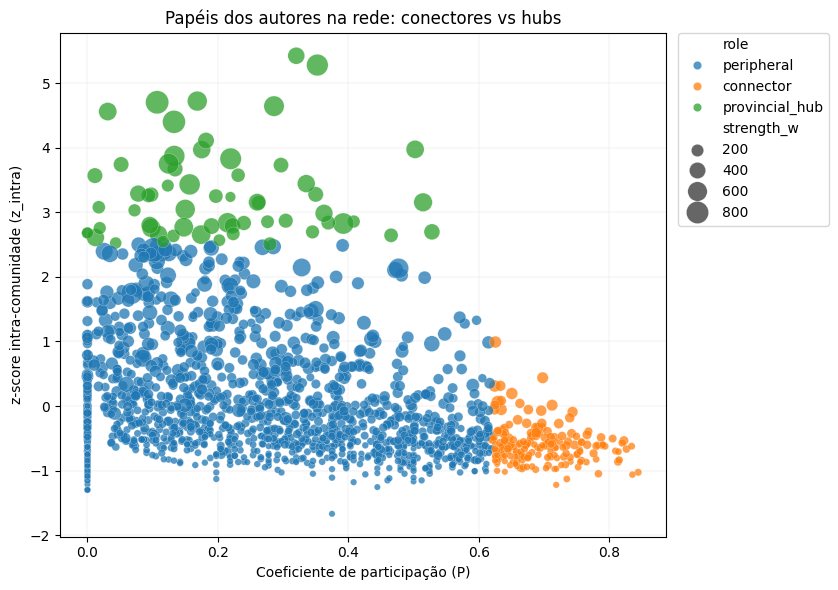

In [31]:
# Garantir colunas esperadas
needed = {"participation_P", "z_intra", "strength_w", "role", "name", "institution", "community"}
missing = needed - set(df_nodes_roles.columns)
if missing:
    raise ValueError(f"df_nodes_roles não tem colunas: {missing}")

plot_df = df_nodes_roles.dropna(subset=["participation_P", "strength_w", "role", "community"]).copy()

# Se z_intra colapsou (≈ 0 para quase todo mundo), recomputa strength_intra_w POR NÓ e z_intra
z_std = float(pd.to_numeric(plot_df.get("z_intra", pd.Series(dtype=float)), errors="coerce").std(skipna=True))
z_maxabs = float(pd.to_numeric(plot_df.get("z_intra", pd.Series(dtype=float)), errors="coerce").abs().max(skipna=True))
if (not np.isfinite(z_std)) or (z_std < 1e-8) or (z_maxabs < 1e-6):
    # Garantir df_intra disponível
    if "df_intra" not in globals():
        if "df_e" not in globals():
            raise ValueError("df_intra/df_e não encontrado. Rode as células que constroem df_e e df_intra antes do plot.")
        df_intra = df_e[df_e["edge_type"] == "intra"].copy()

    # strength_intra_w por nó (soma de pesos intra incidentes no nó)
    intra_by_source = df_intra.groupby("source")["weight"].sum()
    intra_by_target = df_intra.groupby("target")["weight"].sum()
    strength_intra_series = intra_by_source.add(intra_by_target, fill_value=0)

    plot_df["strength_intra_w"] = plot_df["node"].map(strength_intra_series).fillna(0.0)

    # z_intra por comunidade
    plot_df["z_intra"] = (
        plot_df.groupby("community")["strength_intra_w"]
        .transform(zscore_by_group)
    )

    # Reclassificar papel com z_intra corrigido
    plot_df["role"] = plot_df.apply(classify_role, axis=1)

else:
    # Usa z_intra existente, mas garante não-nulo
    plot_df = plot_df.dropna(subset=["z_intra"]).copy()

# Plot
plt.figure(figsize=(8.5, 6.0))
ax = sns.scatterplot(
    data=plot_df,
    x="participation_P",
    y="z_intra",
    hue="role",
    size="strength_w",
    sizes=(20, 300),
    alpha=0.75,
    linewidth=0.2,
    edgecolor="white",
)

ax.set_xlabel("Coeficiente de participação (P)")
ax.set_ylabel("z-score intra-comunidade (z_intra)")
ax.set_title("Papéis dos autores na rede: conectores vs hubs")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
ax.grid(True, which="major", linewidth=0.3, alpha=0.4)

plt.tight_layout()

# Salvar
OUTFIG = os.path.join(DATASET_DIRECTORY, "04-visualization", "figures")
os.makedirs(OUTFIG, exist_ok=True)
plt.savefig(os.path.join(OUTFIG, "fig_papeis_autores_scatter.pdf"), dpi=300, bbox_inches="tight")
plt.show()
# Garantir colunas esperadas
needed = {"participation_P", "z_intra", "strength_w", "role", "name", "institution", "community"}
missing = needed - set(df_nodes_roles.columns)
if missing:
    raise ValueError(f"df_nodes_roles não tem colunas: {missing}")


In [32]:
node_to_community = df_nodes_roles.set_index("node")["community"].to_dict()
df_productions["community"] = df_productions["nid"].map(node_to_community)

df_productions[["nid", "name", "institution", "community"]].head(10)


,nid,name,institution,community
0,1714,Vitor Valério de Souza Campos,UEL,1.0
1,1714,Vitor Valério de Souza Campos,UEL,1.0
2,1714,Vitor Valério de Souza Campos,UEL,1.0
3,1714,Vitor Valério de Souza Campos,UEL,1.0
4,1714,Vitor Valério de Souza Campos,UEL,1.0
5,1714,Vitor Valério de Souza Campos,UEL,1.0
6,1714,Vitor Valério de Souza Campos,UEL,1.0
7,1714,Vitor Valério de Souza Campos,UEL,1.0
8,1714,Vitor Valério de Souza Campos,UEL,1.0
9,1714,Vitor Valério de Souza Campos,UEL,1.0


In [33]:
df_productions.head(10)

,production_id,name,citation,nid,lattes_id,institution,production,aid,authors,type,year,issn,community
0,0,Vitor Valério de Souza Campos,"[Vitor Valério de Souza Campos, CAMPOS, VITOR ...",1714,2809980784526040,UEL,Review and comparison of works on heterogeneou...,1714,Vitor Valério de Souza Campos,PERIODICO,2021,16790375,1.0
1,0,Vitor Valério de Souza Campos,"[Vitor Valério de Souza Campos, CAMPOS, VITOR ...",1714,2809980784526040,UEL,Review and comparison of works on heterogeneou...,778,Jacques Duílio Brancher,PERIODICO,2021,16790375,1.0
2,0,Vitor Valério de Souza Campos,"[Vitor Valério de Souza Campos, CAMPOS, VITOR ...",1714,2809980784526040,UEL,Review and comparison of works on heterogeneou...,39238,"FARIAS, FRANCYELCYO PUSSI",PERIODICO,2021,16790375,1.0
3,0,Vitor Valério de Souza Campos,"[Vitor Valério de Souza Campos, CAMPOS, VITOR ...",1714,2809980784526040,UEL,Review and comparison of works on heterogeneou...,75104,"MIONI, JOSÉ LUIZ VILLELA MARCONDES",PERIODICO,2021,16790375,1.0
4,0,Vitor Valério de Souza Campos,"[Vitor Valério de Souza Campos, CAMPOS, VITOR ...",1714,2809980784526040,UEL,Review and comparison of works on heterogeneou...,14939,"BRAHIM, PEDRO LUIZ GARBIM",PERIODICO,2021,16790375,1.0
5,1,Vitor Valério de Souza Campos,"[Vitor Valério de Souza Campos, CAMPOS, VITOR ...",1714,2809980784526040,UEL,Ecossistemas de big data: uma revisão sistemática,1714,Vitor Valério de Souza Campos,PERIODICO,2023,25258761,1.0
6,2,Vitor Valério de Souza Campos,"[Vitor Valério de Souza Campos, CAMPOS, VITOR ...",1714,2809980784526040,UEL,Knowledge Discovery Using an Integration of Cl...,1714,Vitor Valério de Souza Campos,PERIODICO,2015,23315075,1.0
7,2,Vitor Valério de Souza Campos,"[Vitor Valério de Souza Campos, CAMPOS, VITOR ...",1714,2809980784526040,UEL,Knowledge Discovery Using an Integration of Cl...,23115,Carlos Bueno,PERIODICO,2015,23315075,1.0
8,2,Vitor Valério de Souza Campos,"[Vitor Valério de Souza Campos, CAMPOS, VITOR ...",1714,2809980784526040,UEL,Knowledge Discovery Using an Integration of Cl...,56561,Jacques Duilio Brancher,PERIODICO,2015,23315075,1.0
9,2,Vitor Valério de Souza Campos,"[Vitor Valério de Souza Campos, CAMPOS, VITOR ...",1714,2809980784526040,UEL,Knowledge Discovery Using an Integration of Cl...,42324,Fabio Matsunaga,PERIODICO,2015,23315075,1.0


In [34]:
# Autores sem comunidade (isolados, excluídos do grafo)
isolated = df_productions[df_productions["community"].isna()]
isolated_authors = (
    isolated.groupby("nid")
    .agg(name=("name", "first"), institution=("institution", "first"))
    .reset_index()
)

print(f"Autores isolados: {len(isolated_authors)}")
isolated_authors


Autores isolados: 31


,nid,name,institution
0,15,Adriano Augusto de Moraes Sarmento,UFPE
1,27,Alair Pereira do Lago,USP-SINF
2,80,Altemir da Silva Braga,UFAC
3,91,Ana Cristina Vieira de Melo,USP-SINF
4,401,Deisemara Ferreira,UFSCAR
5,448,Edjard de Souza Mota,UFAM
6,506,Elvio João Leonardo,UEM
7,515,Emilio Del Moral Hernandez,USP-SINF
8,517,Enio Roberto Ribeiro,UNIFEI
9,568,Felipe Fernandes Fanchini,UNESP-SJRP
